In [1]:
# Importing libraries  
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

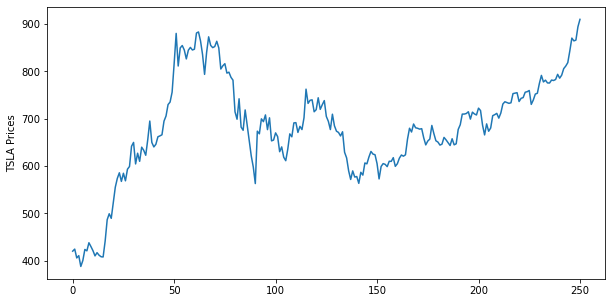

In [2]:
# Read data 
Df = pd.read_csv("TSLA.csv", sep=",")
# Only keep close columns 
Df=Df[['Close']] 
# Drop rows with missing values 
Df= Df.dropna() 
Df.Close.plot(figsize=(10,5)) 
plt.ylabel("TSLA Prices")
plt.show()

In [3]:
Df['S_3'] = Df['Close'].shift(1).rolling(window=3).mean() 
Df['S_9']= Df['Close'].shift(1).rolling(window=9).mean() 
Df= Df.dropna() 
X = Df[['S_3','S_9']] 
X.head()

,S_3,S_9
9,427.656667,414.814443
10,429.673340,415.888889
11,429.766673,415.508891
12,420.523336,415.991113
13,416.250000,416.691115


In [4]:
y = Df['Close']
y.head()

9     429.950012
10    421.260010
11    410.359985
12    417.130005
13    411.760010
Name: Close, dtype: float64

In [5]:
# I split the data in testing and training sets
t=.5 
t = int(t*len(Df)) 

# Train dataset 
X_train = X[:t] 
y_train = y[:t]  
# Test dataset 
X_test = X[t:] 
y_test = y[t:]

In [6]:
linear = LinearRegression().fit(X_train,y_train)

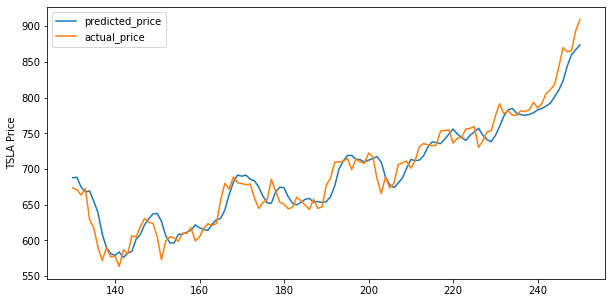

In [7]:
# I plot the predicted price and actual price to see how the model performs.
predicted_price = linear.predict(X_test)  
predicted_price = pd.DataFrame(predicted_price,index=y_test.index,columns = ['price'])  
predicted_price.plot(figsize=(10,5))  
y_test.plot()  
plt.legend(['predicted_price','actual_price'])  
plt.ylabel("TSLA Price")  
plt.show()

In [8]:
r2_score = linear.score(X[t:],y[t:])*100  
float("{0:.2f}".format(r2_score))

94.14

In [9]:
print("The linear regression model does not seem to be an optimal solution for predicting stock prices. I think this is because stock prices is not linear.")

The linear regression model does not seem to be an optimal solution for predicting stock prices. I think this is because stock prices is not linear.
